# Car Brand Classification with OpenCLIP

This notebook uses **OpenCLIP** (an open-source reimplementation of OpenAI's CLIP) to classify car images by brand.  
CLIP (Contrastive Language–Image Pre-training) is a vision-language model that learns to associate images with text descriptions.  
Here, we exploit its **zero-shot** capability: no fine-tuning needed — we simply compare each image embedding against the text embeddings of all brand names.

## Pipeline overview
1. Download the dataset from Kaggle
2. Load an OpenCLIP model
3. Encode all brand names into text embeddings
4. Encode each car image into an image embedding
5. Pick the brand whose text embedding is closest to the image embedding (cosine similarity)
6. Evaluate with accuracy, top-k accuracy, confusion matrix, and per-class metrics

## 1. Install dependencies

In [1]:
!pip install open-clip-torch kagglehub matplotlib seaborn scikit-learn Pillow tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


## 2. Download the dataset

We use `kagglehub` to download the [Car Images Dataset](https://www.kaggle.com/datasets/smlztrkk/car-images-dataset).  
Make sure your Kaggle credentials are configured (`~/.kaggle/kaggle.json` or env variables `KAGGLE_USERNAME` / `KAGGLE_KEY`).

In [ ]:
import kagglehub

# Download latest version

import os
os.listdir('/kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom')

path = '/kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom'
# path = kagglehub.dataset_download("ahmedelsany/car-brand-classification-dataset")

# print("Path to dataset files:", path)

# print("Downloading dataset... (this may take a minute)")
# path = kagglehub.dataset_download("akinduhiman/urban-issues-dataset")
# print(f"\n Dataset downloaded to: {path}")

# path = kagglehub.dataset_download("smlztrkk/car-images-dataset")
# print("Path to dataset files:", path)

## 3. Explore the dataset structure

We inspect the downloaded folder to understand its layout and extract the class (brand) names.

In [3]:
import os
from pathlib import Path
from collections import Counter

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

dataset_root = Path(path)

# ── Auto-detect layout ────────────────────────────────────────────────────────
# Common layout A: root/<brand>/<image>  (one level of subdirs = classes)
# Common layout B: root/<split>/<brand>/<image>  (train/val/test splits)

def collect_samples(root: Path):
    """Return list of (image_path, label) pairs and a sorted list of class names."""
    samples = []
    for p in sorted(root.rglob("*")):
        if p.suffix.lower() in IMAGE_EXTENSIONS and p.parent != root:
            label = p.parent.parent.name          # immediate parent folder = class
            samples.append((p, label))
    class_names = sorted(set(lbl for _, lbl in samples))
    return samples, class_names

samples, class_names = collect_samples(dataset_root)

print(f"Total images found : {len(samples)}")
print(f"Number of classes  : {len(class_names)}")
print(f"Classes            : {class_names}")

# Distribution per class
label_counts = Counter(lbl for _, lbl in samples)
print("\nImages per class:")
for cls in class_names:
    print(f"  {cls:30s} : {label_counts[cls]}")

Total images found : 87163
Number of classes  : 20
Classes            : ['Audi', 'BMW', 'Chevrolet', 'Citroen', 'Dacia', 'Fiat', 'Ford', 'Honda', 'Hyundai', 'Kia', 'Mercedes', 'Nissan', 'Opel', 'Peugeot', 'Renault', 'Seat', 'Skoda', 'Tofaş', 'Toyota', 'Volkswagen']

Images per class:
  Audi                           : 1800
  BMW                            : 3023
  Chevrolet                      : 738
  Citroen                        : 2387
  Dacia                          : 2052
  Fiat                           : 14067
  Ford                           : 8761
  Honda                          : 2406
  Hyundai                        : 3905
  Kia                            : 354
  Mercedes                       : 1883
  Nissan                         : 1000
  Opel                           : 7575
  Peugeot                        : 4184
  Renault                        : 12004
  Seat                           : 1572
  Skoda                          : 1766
  Tofaş                          : 

### Visualise sample images

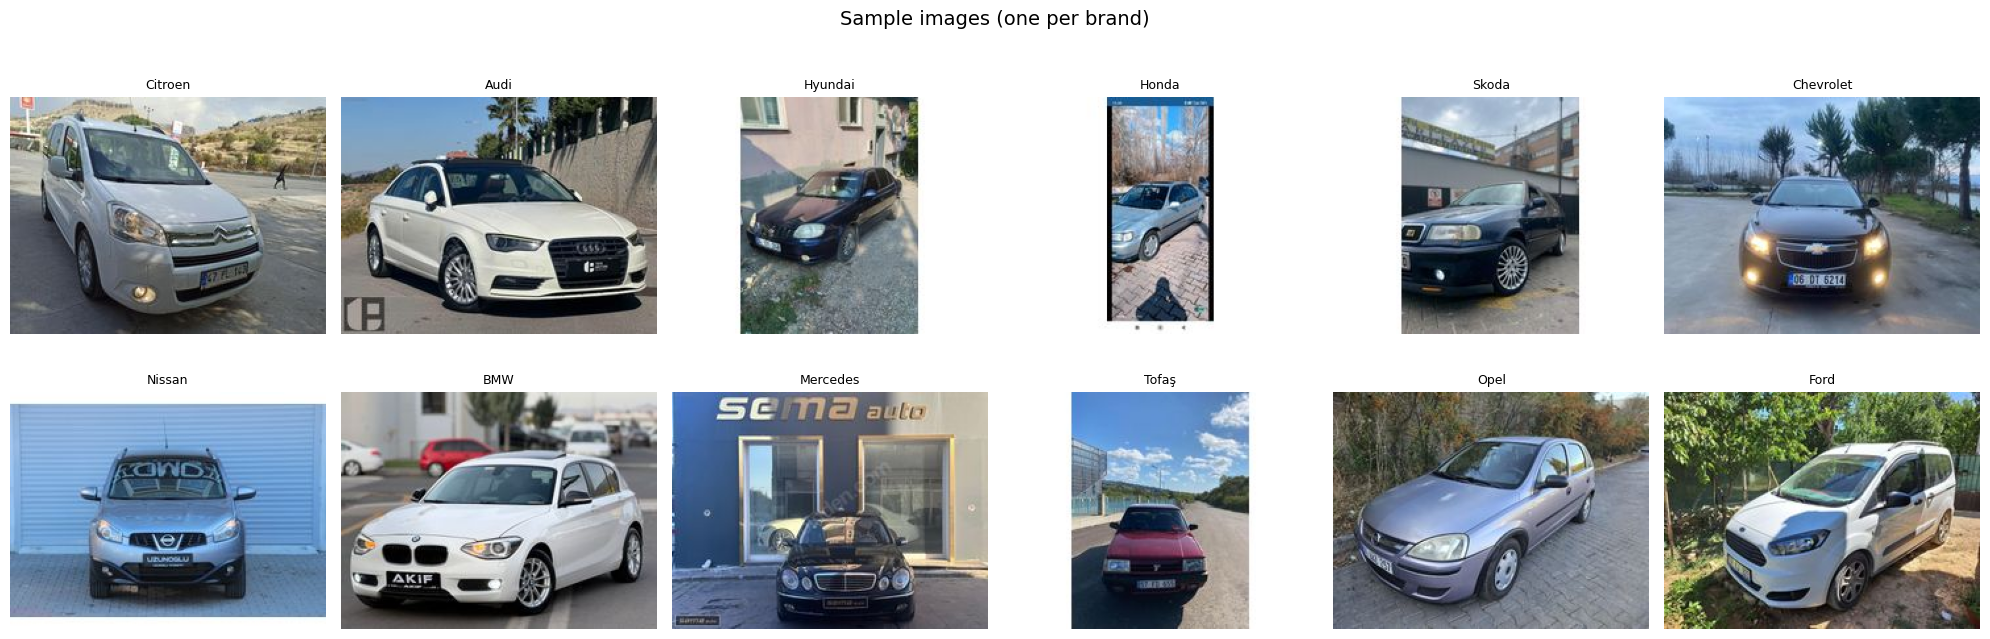

In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)
n_show = min(12, len(class_names))      # show at most 12 brands
shown_classes = random.sample(class_names, n_show)

fig, axes = plt.subplots(2, n_show // 2, figsize=(20, 7))
axes = axes.flatten()

for ax, cls in zip(axes, shown_classes):
    # pick a random image for this class
    candidates = [p for p, lbl in samples if lbl == cls]
    img_path = random.choice(candidates)
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis("off")

plt.suptitle("Sample images (one per brand)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Load OpenCLIP model

We use `ViT-B-32` pre-trained on `laion2b_s34b_b79k` — a strong open-source checkpoint.  
Other good options: `ViT-L-14` (higher accuracy, heavier) or `ViT-B-16`.

OpenCLIP returns:
- `model` — the CLIP model
- `_` — the train-time transform (not needed)
- `preprocess` — the inference-time image transform we will use

In [5]:
import torch
import open_clip

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

MODEL_NAME    = "ViT-B-32"
PRETRAINED    = "laion2b_s34b_b79k"

model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME, pretrained=PRETRAINED, device=DEVICE
)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

model.eval()
print(f"Model '{MODEL_NAME}' loaded (pretrained on {PRETRAINED}).")

Using device: cuda


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Model 'ViT-B-32' loaded (pretrained on laion2b_s34b_b79k).


## 5. Encode class names into text embeddings

For each brand we create the prompt `"<BrandName>"` and encode it with CLIP's text encoder.  
These embeddings form our **classifier weight matrix** — one vector per class.

In [6]:
import torch.nn.functional as F

# Build one text prompt per brand  ─────────────────────────────────────────────
# We use just the brand name as requested.
# Tip: for better accuracy you could try templates like "a photo of a {brand} car"
prompts = class_names          # e.g. ["Toyota", "BMW", ...]

with torch.no_grad():
    tokens         = tokenizer(prompts).to(DEVICE)
    text_embeddings = model.encode_text(tokens)              # (n_classes, D)
    text_embeddings = F.normalize(text_embeddings, dim=-1)   # unit-norm

print(f"Text embedding matrix shape: {text_embeddings.shape}")
print(f"  → {len(class_names)} classes × {text_embeddings.shape[1]}-dim embedding")

Text embedding matrix shape: torch.Size([20, 512])
  → 20 classes × 512-dim embedding


## 6. Zero-shot classification

For every image we:
1. Pre-process it with CLIP's transform
2. Encode it to an image embedding
3. Compute cosine similarity against all text embeddings
4. Apply `softmax` → probability distribution over brands
5. Take `argmax` → predicted class

In [7]:
from tqdm.notebook import tqdm
import numpy as np

BATCH_SIZE = 64          # adjust if you run out of VRAM

class_to_idx = {cls: i for i, cls in enumerate(class_names)}

all_probs   = []          # (N, n_classes) — softmax probabilities
all_preds   = []          # (N,)            — predicted class indices
all_labels  = []          # (N,)            — ground-truth class indices
all_paths   = []          # (N,)            — image paths (for inspection)

# Helper: load and pre-process a list of image paths ─────────────────────────
def load_batch(paths):
    tensors = []
    for p in paths:
        try:
            img = Image.open(p).convert("RGB")
            tensors.append(preprocess(img))
        except Exception as e:
            print(f"Warning – could not open {p}: {e}")
            tensors.append(torch.zeros(3, 224, 224))   # dummy black image
    return torch.stack(tensors)

# Process in batches ──────────────────────────────────────────────────────────
with torch.no_grad():
    for start in tqdm(range(0, len(samples), BATCH_SIZE), desc="Classifying"):
        batch_samples = samples[start : start + BATCH_SIZE]
        paths  = [p   for p, _ in batch_samples]
        labels = [lbl for _, lbl in batch_samples]

        images = load_batch(paths).to(DEVICE)

        img_emb = model.encode_image(images)                   # (B, D)
        img_emb = F.normalize(img_emb, dim=-1)

        # cosine similarity = dot product (both normalised)
        logits  = (img_emb @ text_embeddings.T) * 100         # scale for sharper softmax
        probs   = logits.softmax(dim=-1).cpu().numpy()         # (B, n_classes)
        preds   = probs.argmax(axis=-1)                        # (B,)

        all_probs.extend(probs)
        all_preds.extend(preds.tolist())
        all_labels.extend([class_to_idx[lbl] for lbl in labels])
        all_paths.extend(paths)

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\nClassified {len(all_preds)} images.")

Classifying:   0%|          | 0/1362 [00:00<?, ?it/s]

Warning – could not open /kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Audi/A3/A3_033.jpg: cannot identify image file '/kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Audi/A3/A3_033.jpg'
Warning – could not open /kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Audi/A3/A3_034.jpg: cannot identify image file '/kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Audi/A3/A3_034.jpg'
Warning – could not open /kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Fiat/Doblo/Doblo_1742.jpg: cannot identify image file '/kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Fiat/Doblo/Doblo_1742.jpg'
Warning – could not open /kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Mercedes/C/C_064.jpg: cannot identify image file '/kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Ar

## 7. Metrics

### 7.1 Overall accuracy & top-k accuracy

In [8]:
def top_k_accuracy(probs, labels, k):
    """Fraction of samples where the correct class is in the top-k predictions."""
    top_k = np.argsort(probs, axis=-1)[:, -k:]   # indices of k highest probs
    correct = np.array([labels[i] in top_k[i] for i in range(len(labels))])
    return correct.mean()

top1 = (all_preds == all_labels).mean()
top3 = top_k_accuracy(all_probs, all_labels, k=3)
top5 = top_k_accuracy(all_probs, all_labels, k=5)

print("=" * 35)
print(f"  Top-1 Accuracy : {top1 * 100:.2f} %")
print(f"  Top-3 Accuracy : {top3 * 100:.2f} %")
print(f"  Top-5 Accuracy : {top5 * 100:.2f} %")
print("=" * 35)

  Top-1 Accuracy : 54.21 %
  Top-3 Accuracy : 70.00 %
  Top-5 Accuracy : 78.71 %


### 7.2 Per-class precision, recall, F1

In [9]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report).T
df_report["support"] = df_report["support"].astype(int)

# Show only per-class rows (exclude summary rows)
df_classes = df_report.loc[class_names].sort_values("f1-score", ascending=False)

print("Per-class metrics (sorted by F1):")
print(df_classes[["precision", "recall", "f1-score", "support"]].to_string(float_format="{:.3f}".format))

Per-class metrics (sorted by F1):
            precision  recall  f1-score  support
Mercedes        0.932   0.875     0.903     1883
Audi            0.720   0.932     0.813     1800
Volkswagen      0.952   0.692     0.801    11074
BMW             0.629   0.961     0.760     3023
Toyota          0.815   0.621     0.705     3505
Renault         0.875   0.527     0.658    12004
Ford            0.976   0.494     0.656     8761
Honda           0.572   0.692     0.626     2406
Opel            0.449   0.748     0.561     7575
Chevrolet       0.720   0.412     0.524      738
Peugeot         0.437   0.534     0.480     4184
Citroen         0.312   0.650     0.421     2387
Hyundai         0.476   0.365     0.414     3905
Nissan          0.293   0.700     0.413     1000
Fiat            0.866   0.249     0.387    14067
Dacia           0.213   0.844     0.340     2052
Skoda           0.179   0.830     0.295     1766
Kia             0.077   0.531     0.135      354
Seat            0.077   0.054     0

### 7.3 Confusion matrix

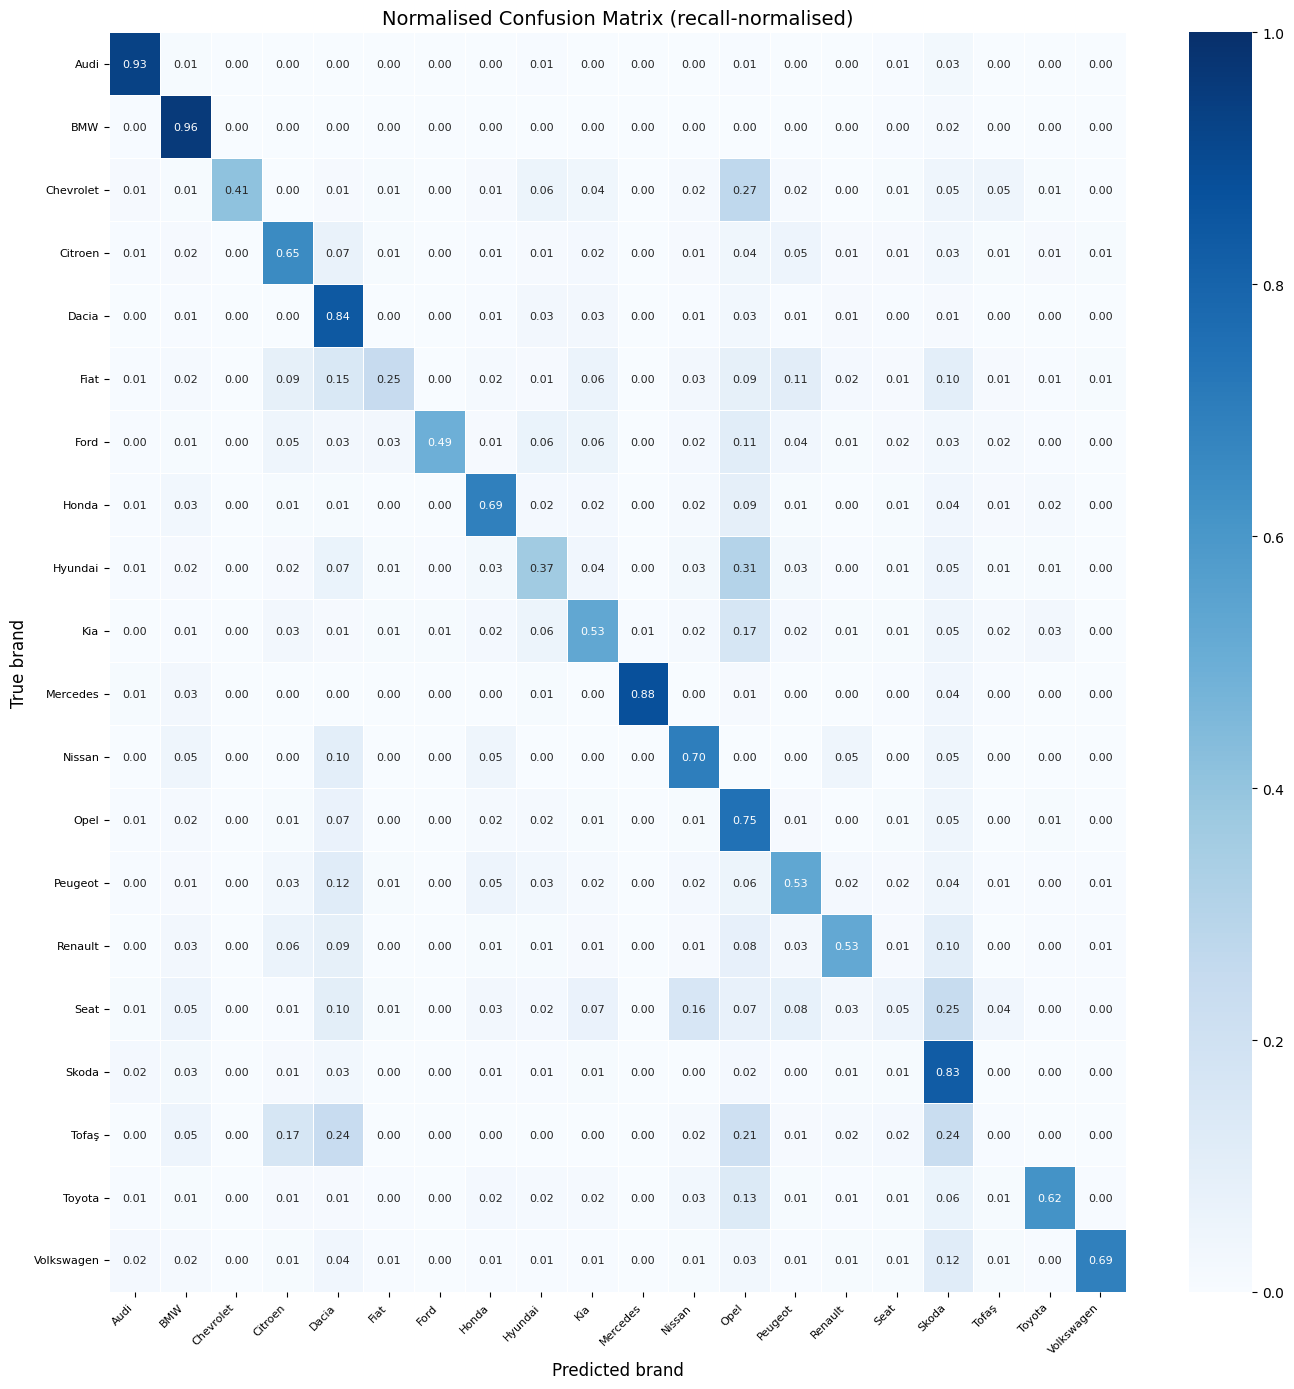

In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

# Normalise by true-class count so colours reflect recall per class
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

n = len(class_names)
fig_size = max(10, n * 0.7)

fig, ax = plt.subplots(figsize=(fig_size, fig_size))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
    linewidths=0.4,
    ax=ax,
    annot_kws={"size": 8},
    vmin=0, vmax=1
)
ax.set_xlabel("Predicted brand", fontsize=12)
ax.set_ylabel("True brand", fontsize=12)
ax.set_title("Normalised Confusion Matrix (recall-normalised)", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### 7.4 Per-class accuracy bar chart

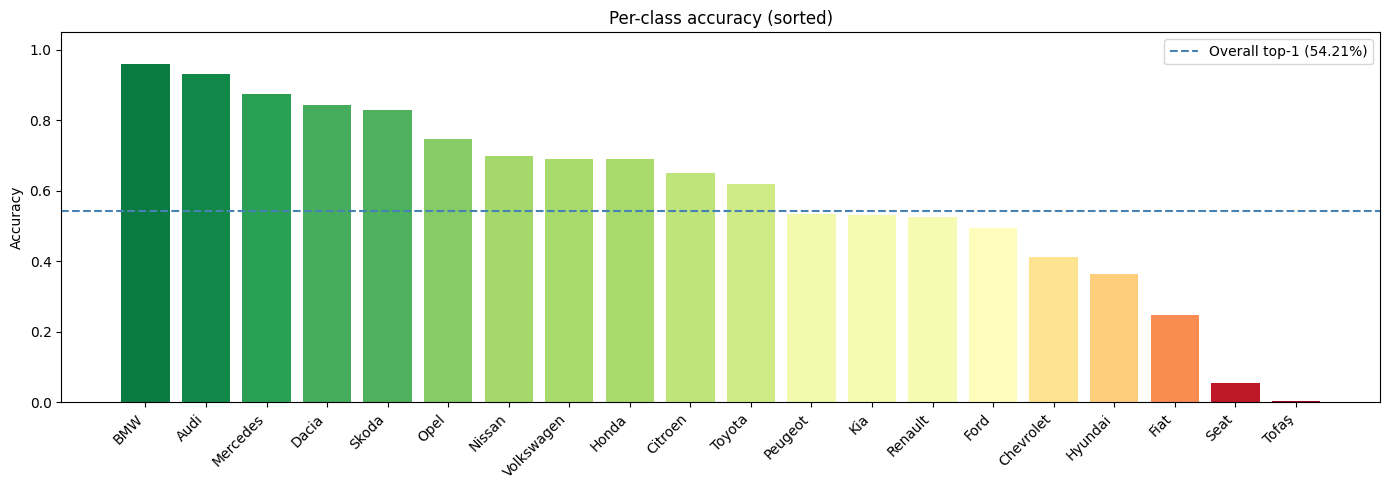

In [11]:
per_class_acc = {
    cls: (cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0.0)
    for i, cls in enumerate(class_names)
}

sorted_classes = sorted(per_class_acc, key=per_class_acc.get, reverse=True)
sorted_accs    = [per_class_acc[c] for c in sorted_classes]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(sorted_classes, sorted_accs, color=plt.cm.RdYlGn(np.array(sorted_accs)))
ax.axhline(top1, color="steelblue", linestyle="--", linewidth=1.5, label=f"Overall top-1 ({top1:.2%})")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Per-class accuracy (sorted)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Qualitative inspection

### 8.1 Correct predictions — high confidence

/tmp/ipykernel_22/1984432937.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


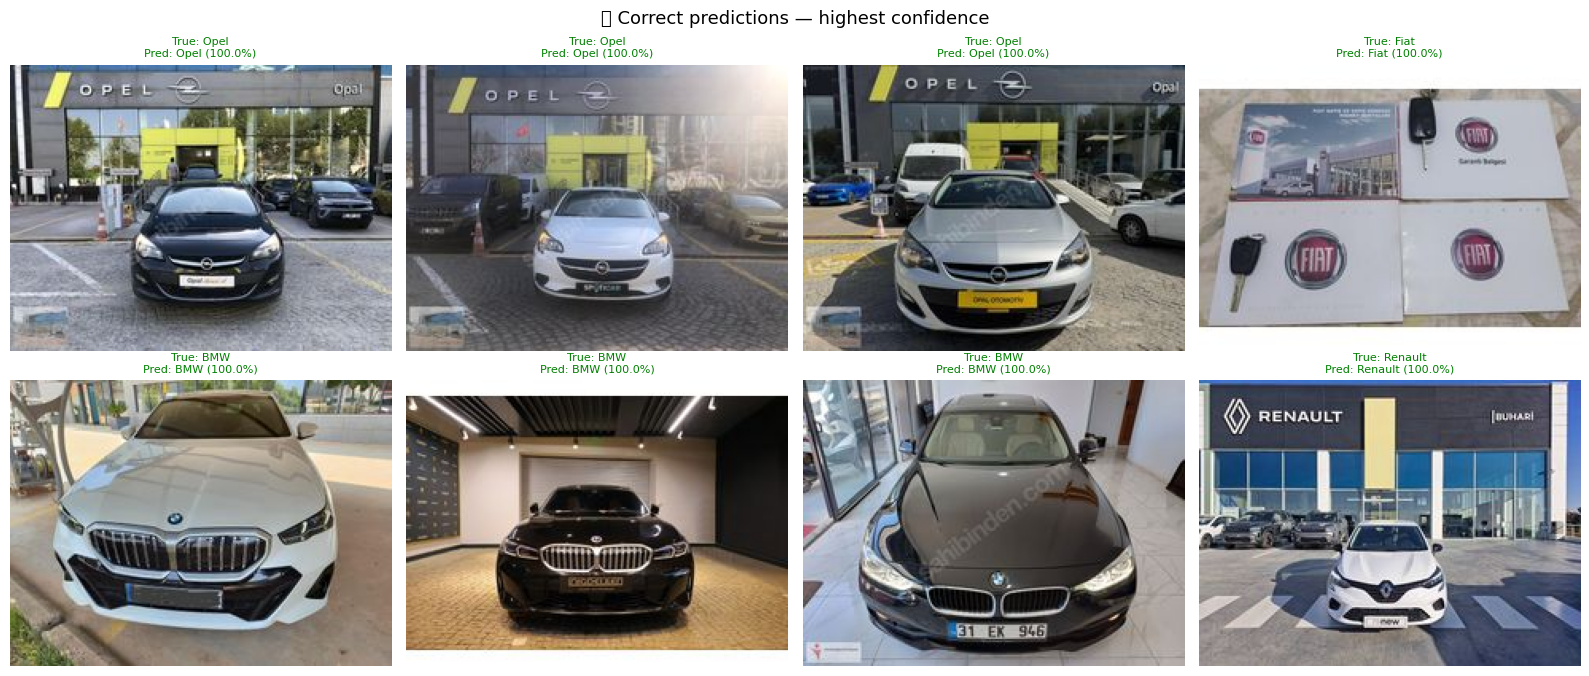

In [ ]:
def show_predictions(indices, title, n=8):
    indices = indices[:n]
    cols = min(n, 4)
    rows = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes = np.array(axes).flatten()

    for ax, idx in zip(axes, indices):
        img = Image.open(all_paths[idx]).convert("RGB")
        true_cls = class_names[all_labels[idx]]
        pred_cls = class_names[all_preds[idx]]
        conf     = all_probs[idx, all_preds[idx]]
        color    = "green" if true_cls == pred_cls else "red"
        ax.imshow(img)
        ax.set_title(
            f"True: {true_cls}\nPred: {pred_cls} ({conf:.1%})",
            fontsize=8, color=color
        )
        ax.axis("off")

    for ax in axes[len(indices):]:
        ax.axis("off")

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# Correct & high-confidence
correct_mask  = all_preds == all_labels
correct_confs = np.where(correct_mask, all_probs[np.arange(len(all_preds)), all_preds], 0)
top_correct   = np.argsort(correct_confs)[::-1]

show_predictions(top_correct, "Correct predictions — highest confidence", n=8)

### 8.2 Wrong predictions — high confidence (most confusing errors)

/tmp/ipykernel_22/1984432937.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


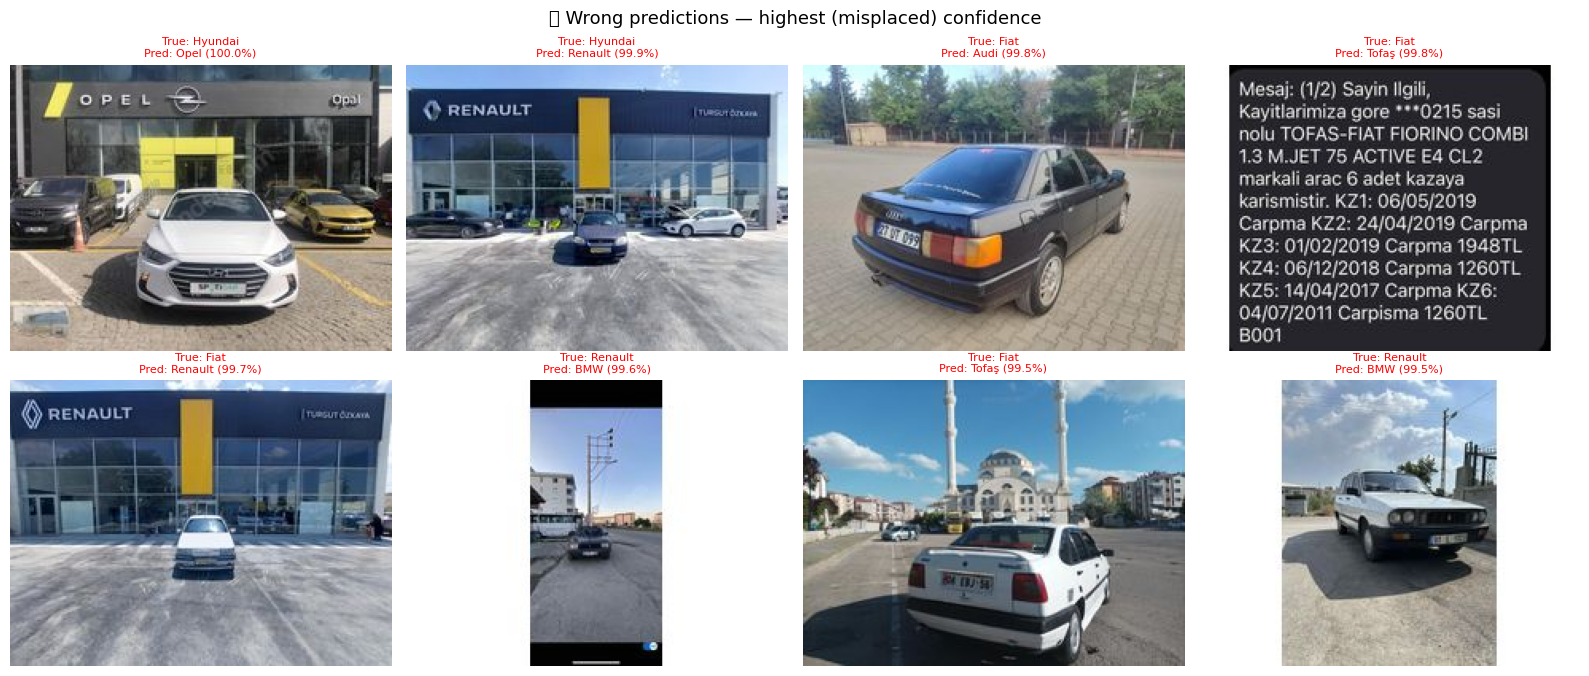

In [ ]:
wrong_mask  = all_preds != all_labels
wrong_confs = np.where(wrong_mask, all_probs[np.arange(len(all_preds)), all_preds], 0)
top_wrong   = np.argsort(wrong_confs)[::-1]

show_predictions(top_wrong, "Wrong predictions — highest (misplaced) confidence", n=8)

### 8.3 Probability distribution for one image

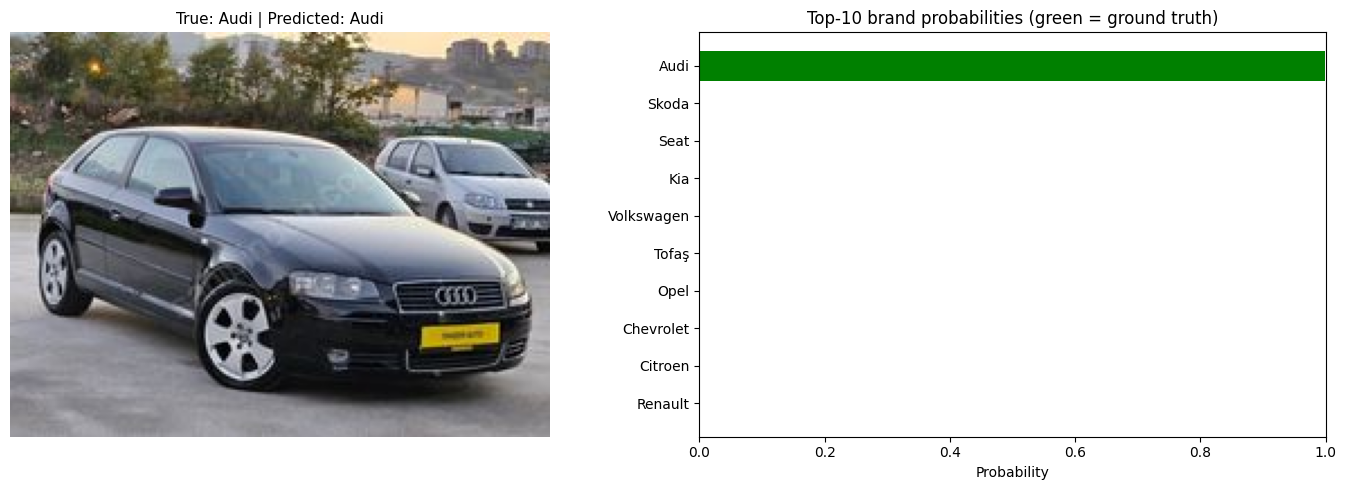

In [14]:
# Pick any image index to inspect
INSPECT_IDX = 0     # ← change this to any sample index

img        = Image.open(all_paths[INSPECT_IDX]).convert("RGB")
true_cls   = class_names[all_labels[INSPECT_IDX]]
pred_cls   = class_names[all_preds[INSPECT_IDX]]
probs_here = all_probs[INSPECT_IDX]

# Top-10 brands
top10_idx   = np.argsort(probs_here)[::-1][:10]
top10_names = [class_names[i] for i in top10_idx]
top10_probs = probs_here[top10_idx]

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(14, 5))

ax_img.imshow(img)
ax_img.set_title(f"True: {true_cls} | Predicted: {pred_cls}", fontsize=11)
ax_img.axis("off")

colors = ["green" if n == true_cls else "steelblue" for n in top10_names]
ax_bar.barh(top10_names[::-1], top10_probs[::-1], color=colors[::-1])
ax_bar.set_xlabel("Probability")
ax_bar.set_title("Top-10 brand probabilities (green = ground truth)")
ax_bar.set_xlim(0, 1)

plt.tight_layout()
plt.show()

---
# Part 2 — Linear Probe

## 10. What is a linear probe?

A **linear probe** keeps the CLIP image encoder **completely frozen** and trains only a single fully-connected layer (`nn.Linear`) on top of the frozen embeddings.  

Compared to zero-shot:
- The classifier **learns from labelled examples** instead of relying on text-image alignment
- Training is very fast because embeddings are extracted once and reused
- No risk of destroying CLIP's general representations

### Pipeline
1. Extract image embeddings for every sample (one forward pass, done once)
2. Split into train / validation / test sets
3. Train `nn.Linear(D, n_classes)` with cross-entropy loss
4. Evaluate on the test set and compare against zero-shot

## 11. Extract all image embeddings

We run every image through the frozen CLIP encoder **once** and cache the embeddings.  
This is the most expensive step, but it only needs to happen once regardless of how many epochs we train.

In [15]:
# Re-use the load_batch helper and model from Part 1
# (make sure Part 1 cells have been run first)

all_embeddings = []   # will hold one L2-normalised vector per image
all_gt_labels  = []   # integer labels, same order as all_embeddings

model.eval()
with torch.no_grad():
    for start in tqdm(range(0, len(samples), BATCH_SIZE), desc="Extracting embeddings"):
        batch_samples = samples[start : start + BATCH_SIZE]
        paths  = [p   for p, _ in batch_samples]
        labels = [lbl for _, lbl in batch_samples]

        images = load_batch(paths).to(DEVICE)
        emb    = model.encode_image(images)            # (B, D)
        emb    = F.normalize(emb, dim=-1).cpu()        # unit-norm, move to CPU

        all_embeddings.append(emb)
        all_gt_labels.extend([class_to_idx[lbl] for lbl in labels])

all_embeddings = torch.cat(all_embeddings, dim=0)      # (N, D)
all_gt_labels  = torch.tensor(all_gt_labels)           # (N,)

print(f"Embeddings shape : {all_embeddings.shape}")
print(f"Labels shape     : {all_gt_labels.shape}")

Extracting embeddings:   0%|          | 0/1362 [00:00<?, ?it/s]

Warning – could not open /kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Audi/A3/A3_033.jpg: cannot identify image file '/kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Audi/A3/A3_033.jpg'
Warning – could not open /kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Audi/A3/A3_034.jpg: cannot identify image file '/kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Audi/A3/A3_034.jpg'
Warning – could not open /kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Fiat/Doblo/Doblo_1742.jpg: cannot identify image file '/kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Fiat/Doblo/Doblo_1742.jpg'
Warning – could not open /kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Arabamcom/Mercedes/C/C_064.jpg: cannot identify image file '/kaggle/input/datasets/smlztrkk/car-images-dataset/Car_Images_Dataset_Ar

## 12. Train / val / test split

We do a stratified split so every brand is represented proportionally in each set:
- **70 %** training
- **15 %** validation (used to monitor training and pick the best epoch)
- **15 %** test (held out until final evaluation)

In [16]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(all_gt_labels))
labels_np = all_gt_labels.numpy()

# First split: 70 % train, 30 % temp
idx_train, idx_temp = train_test_split(
    indices, test_size=0.30, stratify=labels_np, random_state=42
)
# Second split: 50/50 of the 30 % → 15 % val, 15 % test
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=labels_np[idx_temp], random_state=42
)

X_train = all_embeddings[idx_train]
y_train = all_gt_labels[idx_train]
X_val   = all_embeddings[idx_val]
y_val   = all_gt_labels[idx_val]
X_test  = all_embeddings[idx_test]
y_test  = all_gt_labels[idx_test]

print(f"Train : {len(X_train)} samples")
print(f"Val   : {len(X_val)} samples")
print(f"Test  : {len(X_test)} samples")

Train : 61014 samples
Val   : 13074 samples
Test  : 13075 samples


## 13. Define and train the linear probe

The probe is a single `nn.Linear(D, n_classes)` layer trained with:
- **Cross-entropy loss**
- **Adam optimiser** with a mild weight-decay (L2 regularisation)
- Early stopping based on validation loss to avoid over-fitting

In [ ]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ── Hyper-parameters ──────────────────────────────────────────────────────────
LP_EPOCHS      = 50
LP_BATCH_SIZE  = 256
LP_LR          = 1e-3
LP_WEIGHT_DECAY = 1e-4
PATIENCE       = 7       # early stopping patience (epochs)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)

train_loader = DataLoader(train_ds, batch_size=LP_BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=LP_BATCH_SIZE, shuffle=False)

# ── Model ─────────────────────────────────────────────────────────────────────
embed_dim  = all_embeddings.shape[1]   # 512 for ViT-B-32
n_classes  = len(class_names)

linear_probe = nn.Linear(embed_dim, n_classes).to(DEVICE)

criterion  = nn.CrossEntropyLoss()
optimiser  = torch.optim.Adam(
    linear_probe.parameters(), lr=LP_LR, weight_decay=LP_WEIGHT_DECAY
)

# ── Training loop ─────────────────────────────────────────────────────────────
best_val_loss   = float("inf")
best_state      = None
patience_counter = 0

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, LP_EPOCHS + 1):
    # — Train —
    linear_probe.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        logits = linear_probe(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimiser.step()
        t_loss    += loss.item() * len(xb)
        t_correct += (logits.argmax(1) == yb).sum().item()
        t_total   += len(xb)

    # — Validate —
    linear_probe.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = linear_probe(xb)
            loss   = criterion(logits, yb)
            v_loss    += loss.item() * len(xb)
            v_correct += (logits.argmax(1) == yb).sum().item()
            v_total   += len(xb)

    t_loss_avg = t_loss / t_total
    v_loss_avg = v_loss / v_total
    t_acc      = t_correct / t_total
    v_acc      = v_correct / v_total

    train_losses.append(t_loss_avg);  val_losses.append(v_loss_avg)
    train_accs.append(t_acc);         val_accs.append(v_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{LP_EPOCHS} | "
              f"Train loss: {t_loss_avg:.4f} acc: {t_acc:.3f} | "
              f"Val loss: {v_loss_avg:.4f} acc: {v_acc:.3f}")

    # — Early stopping —
    if v_loss_avg < best_val_loss:
        best_val_loss = v_loss_avg
        best_state    = {k: v.clone() for k, v in linear_probe.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

# Restore best weights
linear_probe.load_state_dict(best_state)
print("\n Training complete — best model restored.")

Epoch   1/50 | Train loss: 2.4197 acc: 0.377 | Val loss: 2.0726 acc: 0.473
Epoch   5/50 | Train loss: 1.1830 acc: 0.711 | Val loss: 1.1251 acc: 0.722
Epoch  10/50 | Train loss: 0.9103 acc: 0.762 | Val loss: 0.8943 acc: 0.764
Epoch  15/50 | Train loss: 0.8342 acc: 0.778 | Val loss: 0.8274 acc: 0.780
Epoch  20/50 | Train loss: 0.8055 acc: 0.785 | Val loss: 0.8022 acc: 0.784
Epoch  25/50 | Train loss: 0.7927 acc: 0.789 | Val loss: 0.7909 acc: 0.787
Epoch  30/50 | Train loss: 0.7865 acc: 0.790 | Val loss: 0.7854 acc: 0.791
Epoch  35/50 | Train loss: 0.7830 acc: 0.791 | Val loss: 0.7824 acc: 0.789
Epoch  40/50 | Train loss: 0.7809 acc: 0.793 | Val loss: 0.7808 acc: 0.788
Epoch  45/50 | Train loss: 0.7797 acc: 0.792 | Val loss: 0.7796 acc: 0.791
Epoch  50/50 | Train loss: 0.7788 acc: 0.793 | Val loss: 0.7786 acc: 0.793

✅ Training complete — best model restored.


In [18]:
import json

# ── Save the linear probe to Kaggle's output directory ───────────────────────
OUTPUT_DIR = Path("/kaggle/working/linear_probe")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Model weights
torch.save(best_state, OUTPUT_DIR / "linear_probe_weights.pt")

# 2. Class names — needed to map indices back to brand names when reloading
with open(OUTPUT_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f)

# 3. Model config — so you know which CLIP backbone produced the embeddings
config = {"clip_model": MODEL_NAME, "pretrained": PRETRAINED, "embed_dim": embed_dim, "n_classes": n_classes}
with open(OUTPUT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Saved to {OUTPUT_DIR}:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {p.name}")

Saved to /kaggle/working/linear_probe:
  class_names.json
  config.json
  linear_probe_weights.pt


## 14. Training curves

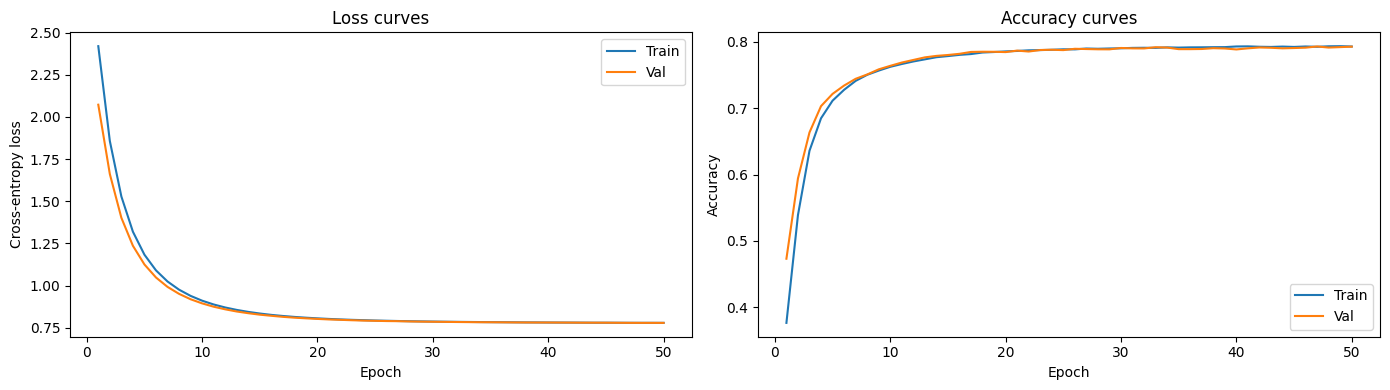

In [19]:
epochs_ran = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(epochs_ran, train_losses, label="Train")
ax1.plot(epochs_ran, val_losses,   label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("Loss curves"); ax1.legend()

ax2.plot(epochs_ran, train_accs, label="Train")
ax2.plot(epochs_ran, val_accs,   label="Val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy curves"); ax2.legend()

plt.tight_layout()
plt.show()

## 15. Evaluate the linear probe on the test set

In [20]:
linear_probe.eval()

with torch.no_grad():
    logits_test = linear_probe(X_test.to(DEVICE)).cpu()   # (N_test, n_classes)

lp_probs  = logits_test.softmax(dim=-1).numpy()
lp_preds  = lp_probs.argmax(axis=-1)
lp_labels = y_test.numpy()

lp_top1 = (lp_preds == lp_labels).mean()
lp_top3 = top_k_accuracy(lp_probs, lp_labels, k=3)
lp_top5 = top_k_accuracy(lp_probs, lp_labels, k=5)

print("=" * 50)
print(f"  {'Metric':<20} {'Zero-shot':>10}  {'Linear probe':>12}")
print("-" * 50)
# Zero-shot numbers come from Part 1 (all_probs / all_labels cover the full dataset)
# For a fair comparison we compute zero-shot on the same test indices
zs_probs_test  = all_probs[idx_test]
zs_preds_test  = zs_probs_test.argmax(axis=-1)
zs_labels_test = labels_np[idx_test]
zs_top1_test   = (zs_preds_test == zs_labels_test).mean()
zs_top3_test   = top_k_accuracy(zs_probs_test, zs_labels_test, k=3)
zs_top5_test   = top_k_accuracy(zs_probs_test, zs_labels_test, k=5)

print(f"  {'Top-1 Accuracy':<20} {zs_top1_test*100:>9.2f}%  {lp_top1*100:>11.2f}%")
print(f"  {'Top-3 Accuracy':<20} {zs_top3_test*100:>9.2f}%  {lp_top3*100:>11.2f}%")
print(f"  {'Top-5 Accuracy':<20} {zs_top5_test*100:>9.2f}%  {lp_top5*100:>11.2f}%")
print("=" * 50)

  Metric                Zero-shot  Linear probe
--------------------------------------------------
  Top-1 Accuracy           54.95%        79.79%
  Top-3 Accuracy           70.49%        92.12%
  Top-5 Accuracy           79.17%        95.89%


## 16. Linear probe — confusion matrix & per-class metrics

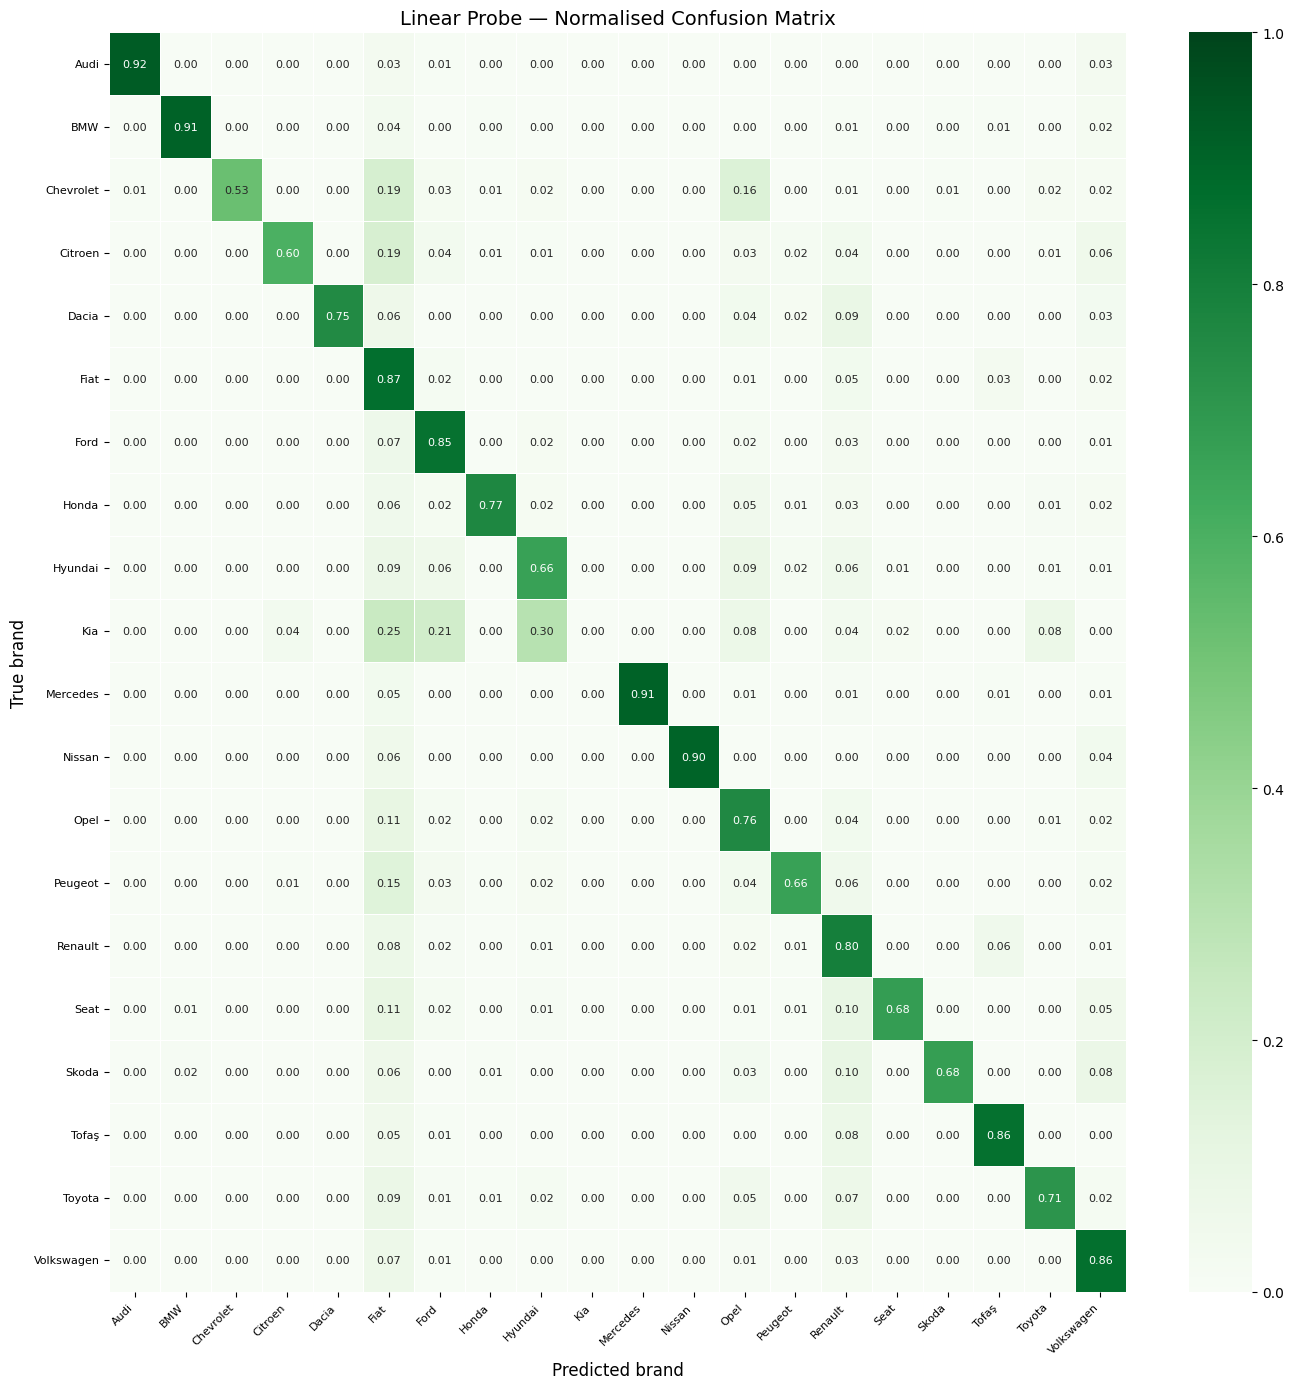

In [21]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm_lp      = confusion_matrix(lp_labels, lp_preds)
cm_lp_norm = cm_lp.astype(float) / cm_lp.sum(axis=1, keepdims=True)

fig_size = max(10, len(class_names) * 0.7)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))
sns.heatmap(
    cm_lp_norm, annot=True, fmt=".2f",
    xticklabels=class_names, yticklabels=class_names,
    cmap="Greens", linewidths=0.4, ax=ax,
    annot_kws={"size": 8}, vmin=0, vmax=1
)
ax.set_xlabel("Predicted brand", fontsize=12)
ax.set_ylabel("True brand", fontsize=12)
ax.set_title("Linear Probe — Normalised Confusion Matrix", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

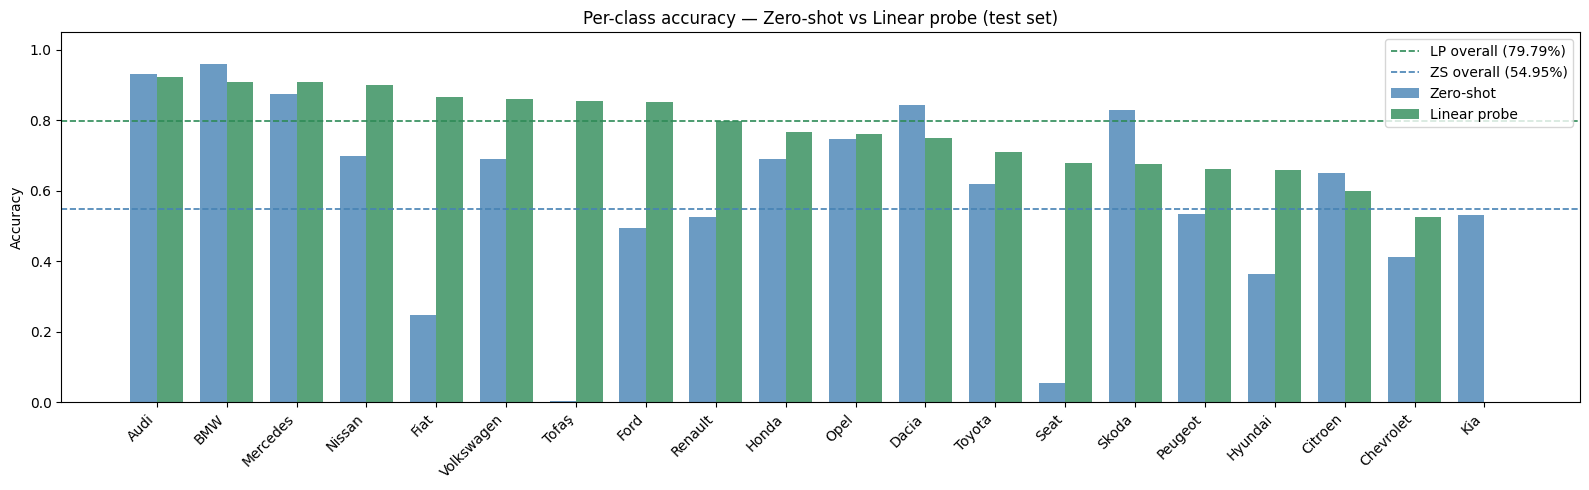

In [22]:
# ── Per-class accuracy comparison bar chart ───────────────────────────────────
lp_per_class_acc = {
    cls: (cm_lp[i, i] / cm_lp[i].sum() if cm_lp[i].sum() > 0 else 0.0)
    for i, cls in enumerate(class_names)
}
zs_per_class_acc = {
    cls: (per_class_acc[cls])   # computed in Part 1 §7.4 over the full dataset
    for cls in class_names
}

sorted_cls = sorted(lp_per_class_acc, key=lp_per_class_acc.get, reverse=True)
x = np.arange(len(sorted_cls))
w = 0.38

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w/2, [zs_per_class_acc[c] for c in sorted_cls], w,
       label="Zero-shot", color="steelblue", alpha=0.8)
ax.bar(x + w/2, [lp_per_class_acc[c] for c in sorted_cls], w,
       label="Linear probe", color="seagreen", alpha=0.8)
ax.axhline(lp_top1, color="seagreen",  linestyle="--", linewidth=1.2,
           label=f"LP overall ({lp_top1:.2%})")
ax.axhline(zs_top1_test, color="steelblue", linestyle="--", linewidth=1.2,
           label=f"ZS overall ({zs_top1_test:.2%})")
ax.set_xticks(x)
ax.set_xticklabels(sorted_cls, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Per-class accuracy — Zero-shot vs Linear probe (test set)")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# ── Per-class classification report ──────────────────────────────────────────
lp_report = classification_report(
    lp_labels, lp_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)
df_lp = pd.DataFrame(lp_report).T
df_lp["support"] = df_lp["support"].astype(int)
df_lp_classes = df_lp.loc[class_names].sort_values("f1-score", ascending=False)

print("Linear probe — per-class metrics (sorted by F1):")
print(df_lp_classes[["precision", "recall", "f1-score", "support"]].to_string(
    float_format="{:.3f}".format
))

Linear probe — per-class metrics (sorted by F1):
            precision  recall  f1-score  support
Nissan          1.000   0.900     0.947      150
Audi            0.973   0.922     0.947      270
Mercedes        0.977   0.908     0.941      282
BMW             0.954   0.909     0.931      453
Volkswagen      0.862   0.862     0.862     1661
Dacia           0.979   0.750     0.849      308
Ford            0.835   0.852     0.844     1314
Honda           0.908   0.767     0.832      361
Toyota          0.899   0.711     0.794      526
Skoda           0.937   0.675     0.785      265
Seat            0.925   0.678     0.782      236
Renault         0.747   0.798     0.772     1801
Tofaş           0.690   0.856     0.764      466
Opel            0.758   0.762     0.760     1137
Fiat            0.666   0.867     0.753     2110
Peugeot         0.872   0.662     0.753      628
Citroen         0.964   0.601     0.740      358
Hyundai         0.754   0.660     0.704      586
Chevrolet       0.96

## 17. Summary

| Metric | Zero-shot (full dataset) | Linear probe (test set) |
|--------|--------------------------|-------------------------|
| Top-1 Accuracy | see §7.1 | see §15 |
| Top-3 Accuracy | see §7.1 | see §15 |
| Top-5 Accuracy | see §7.1 | see §15 |

### Key takeaways
- The linear probe learns task-specific decision boundaries from labelled data → typically outperforms zero-shot
- Training is fast because embeddings are extracted once and the only trainable part is a single matrix
- If the gap is still large, consider **partial fine-tuning** (unfreeze last transformer blocks) or **LoRA**
- If classes with few images perform poorly, **data augmentation** or **class-weighted loss** can help